In [7]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU count: {torch.cuda.device_count()}")
    print(f"CUDA version: {torch.version.cuda}")
    
    # Quick GPU computation test
    x = torch.randn(1000, 1000, device='cuda')
    y = torch.randn(1000, 1000, device='cuda')
    z = torch.matmul(x, y)
    print(f"\nGPU matrix multiplication test: PASSED")
    print(f"Tensor device: {z.device}")
    print(f"GPU memory allocated: {torch.cuda.memory_allocated(0) / 1024**2:.1f} MB")
else:
    print("No GPU detected.")


PyTorch version: 2.6.0+cu124
CUDA available: True
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU
GPU count: 1
CUDA version: 12.4

GPU matrix multiplication test: PASSED
Tensor device: cuda:0
GPU memory allocated: 20.0 MB


# Requirement 4: JPEG Corruption Under AWGN — STL-10 Dataset

**Goal**: Determine at what SNR level does AWGN corrupt a JPEG-compressed image significantly.

**Pipeline**:
1. Sample images from STL-10 test set
2. JPEG-compress each image at various quality levels (10, 30, 50, 75, 95)
3. Add AWGN at various SNR levels (0 → 40 dB)
4. Measure image quality (PSNR, SSIM) vs. the clean JPEG reference
5. Identify the SNR threshold where images become noticeably corrupted (PSNR < 30 dB / SSIM < 0.7)


In [8]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import STL10
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import io
import warnings
from skimage.metrics import structural_similarity as ssim

warnings.filterwarnings('ignore')

# Download STL-10 test set (96x96 RGB, 10 classes, 8000 test images)
dataset = STL10(root='../data', split='test', download=True, transform=transforms.ToTensor())
print(f"STL-10 loaded: {len(dataset)} test images | Image size: 96x96 RGB")
print(f"Classes: {dataset.classes}")


STL-10 loaded: 8000 test images | Image size: 96x96 RGB
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [9]:
# ── Helper Functions ──────────────────────────────────────────────────────────

def jpeg_compress(img_uint8: np.ndarray, quality: int) -> np.ndarray:
    """JPEG compress/decompress a uint8 [H,W,3] image. Returns uint8 array."""
    pil_img = Image.fromarray(img_uint8)
    buf = io.BytesIO()
    pil_img.save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    return np.array(Image.open(buf).copy())

def add_awgn(img_float: np.ndarray, snr_db: float) -> np.ndarray:
    """Add AWGN to a float [0,1] image at the given SNR (dB). Returns clipped float."""
    signal_power = np.mean(img_float ** 2)
    if signal_power < 1e-10:
        return img_float.copy()
    noise_std = np.sqrt(signal_power / (10 ** (snr_db / 10)))
    noise = np.random.normal(0, noise_std, img_float.shape)
    return np.clip(img_float + noise, 0.0, 1.0)

def compute_psnr(ref: np.ndarray, noisy: np.ndarray) -> float:
    """PSNR (dB) between two float [0,1] images."""
    mse = np.mean((ref - noisy) ** 2)
    return 100.0 if mse == 0 else 10 * np.log10(1.0 / mse)

def compute_ssim(ref: np.ndarray, noisy: np.ndarray) -> float:
    """SSIM between two float [0,1] RGB images."""
    return ssim(ref, noisy, channel_axis=2, data_range=1.0)

print("Helper functions defined: jpeg_compress, add_awgn, compute_psnr, compute_ssim")


Helper functions defined: jpeg_compress, add_awgn, compute_psnr, compute_ssim


In [10]:
# ── Experiment: PSNR & SSIM vs SNR for each JPEG quality ─────────────────────

N_IMAGES      = 100                              # images sampled from STL-10 test set
SNR_VALUES    = [0, 5, 10, 15, 20, 25, 30, 35, 40]  # dB
JPEG_QUALITIES = [10, 30, 50, 75, 95]

results_psnr = {q: [] for q in JPEG_QUALITIES}
results_ssim = {q: [] for q in JPEG_QUALITIES}

np.random.seed(42)
indices = np.random.choice(len(dataset), N_IMAGES, replace=False)

for q in JPEG_QUALITIES:
    for snr in SNR_VALUES:
        psnr_list, ssim_list = [], []
        for idx in indices:
            img_tensor, _ = dataset[idx]
            img_uint8 = (img_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

            # Step 1 – JPEG compress (this is the "transmitted" reference)
            jpeg_uint8  = jpeg_compress(img_uint8, quality=q)
            jpeg_float  = jpeg_uint8.astype(np.float32) / 255.0

            # Step 2 – add AWGN on top of the JPEG image
            noisy_float = add_awgn(jpeg_float, snr)

            # Measure degradation of received image vs clean JPEG
            psnr_list.append(compute_psnr(jpeg_float, noisy_float))
            ssim_list.append(compute_ssim(jpeg_float, noisy_float))

        results_psnr[q].append(float(np.mean(psnr_list)))
        results_ssim[q].append(float(np.mean(ssim_list)))

    print(f"  JPEG quality {q:3d} ✓  |  "
          f"SNR 0 dB → PSNR={results_psnr[q][0]:.1f} dB, SSIM={results_ssim[q][0]:.3f}  |  "
          f"SNR 40 dB → PSNR={results_psnr[q][-1]:.1f} dB, SSIM={results_ssim[q][-1]:.3f}")

print("\nExperiment complete!")


  JPEG quality  10 ✓  |  SNR 0 dB → PSNR=9.4 dB, SSIM=0.123  |  SNR 40 dB → PSNR=46.4 dB, SSIM=0.994
  JPEG quality  30 ✓  |  SNR 0 dB → PSNR=9.4 dB, SSIM=0.127  |  SNR 40 dB → PSNR=46.4 dB, SSIM=0.994
  JPEG quality  50 ✓  |  SNR 0 dB → PSNR=9.4 dB, SSIM=0.129  |  SNR 40 dB → PSNR=46.4 dB, SSIM=0.994
  JPEG quality  75 ✓  |  SNR 0 dB → PSNR=9.4 dB, SSIM=0.131  |  SNR 40 dB → PSNR=46.4 dB, SSIM=0.994
  JPEG quality  95 ✓  |  SNR 0 dB → PSNR=9.4 dB, SSIM=0.131  |  SNR 40 dB → PSNR=46.4 dB, SSIM=0.994

Experiment complete!


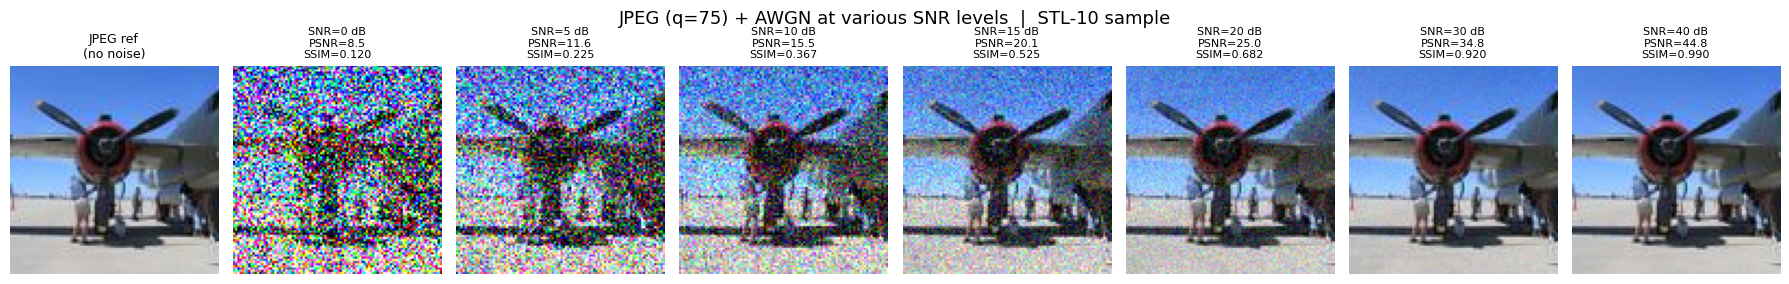

Saved: sample_awgn_jpeg.png


In [11]:
# ── Visual: Sample image at JPEG q=75 across SNR levels ──────────────────────

sample_tensor, sample_label = dataset[indices[0]]
sample_uint8  = (sample_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
jpeg_uint8    = jpeg_compress(sample_uint8, quality=75)
jpeg_float    = jpeg_uint8.astype(np.float32) / 255.0

SHOW_SNRS = [0, 5, 10, 15, 20, 30, 40]
fig, axes = plt.subplots(1, len(SHOW_SNRS) + 1, figsize=(18, 3))
fig.suptitle("JPEG (q=75) + AWGN at various SNR levels  |  STL-10 sample", fontsize=13)

axes[0].imshow(jpeg_uint8)
axes[0].set_title("JPEG ref\n(no noise)", fontsize=9)
axes[0].axis('off')

for ax, snr in zip(axes[1:], SHOW_SNRS):
    noisy = add_awgn(jpeg_float, snr)
    p = compute_psnr(jpeg_float, noisy)
    s = compute_ssim(jpeg_float, noisy)
    ax.imshow(noisy)
    ax.set_title(f"SNR={snr} dB\nPSNR={p:.1f}\nSSIM={s:.3f}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig("results/sample_awgn_jpeg.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sample_awgn_jpeg.png")


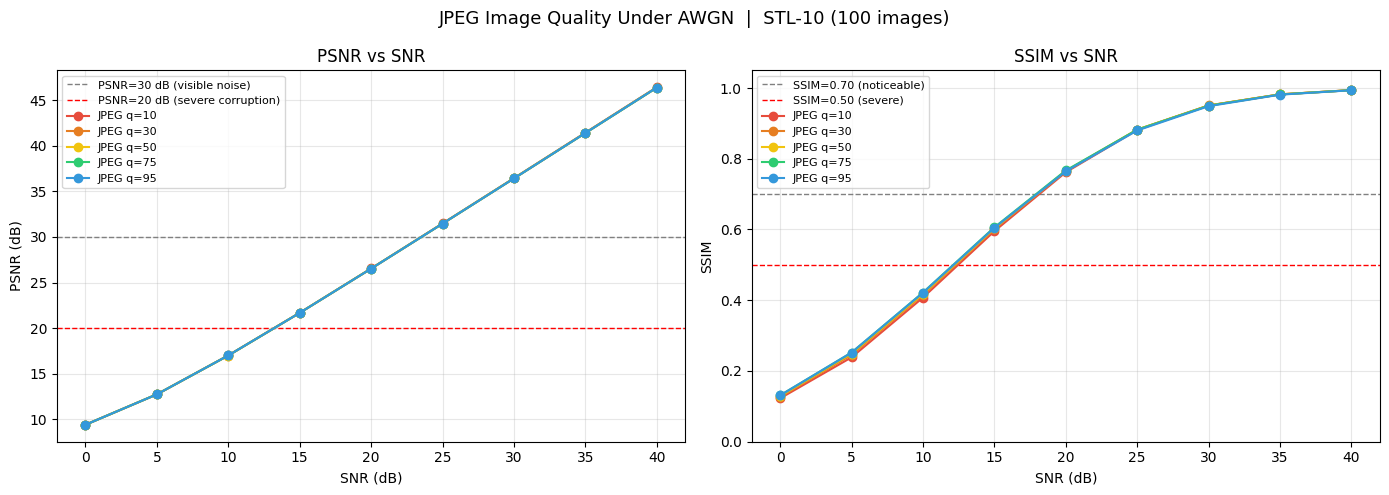

Saved: psnr_ssim_vs_snr.png


In [12]:
# ── Plot: PSNR & SSIM vs SNR for all JPEG qualities ──────────────────────────

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("JPEG Image Quality Under AWGN  |  STL-10 (100 images)", fontsize=13)

# Corruption thresholds
ax1.axhline(30, color='gray', linestyle='--', linewidth=1, label='PSNR=30 dB (visible noise)')
ax1.axhline(20, color='red',  linestyle='--', linewidth=1, label='PSNR=20 dB (severe corruption)')
ax2.axhline(0.7, color='gray', linestyle='--', linewidth=1, label='SSIM=0.70 (noticeable)')
ax2.axhline(0.5, color='red',  linestyle='--', linewidth=1, label='SSIM=0.50 (severe)')

for q, c in zip(JPEG_QUALITIES, colors):
    ax1.plot(SNR_VALUES, results_psnr[q], marker='o', color=c, label=f'JPEG q={q}')
    ax2.plot(SNR_VALUES, results_ssim[q], marker='o', color=c, label=f'JPEG q={q}')

ax1.set_xlabel("SNR (dB)");  ax1.set_ylabel("PSNR (dB)")
ax1.set_title("PSNR vs SNR");  ax1.legend(fontsize=8);  ax1.grid(True, alpha=0.3)
ax1.set_xticks(SNR_VALUES)

ax2.set_xlabel("SNR (dB)");  ax2.set_ylabel("SSIM")
ax2.set_title("SSIM vs SNR");  ax2.legend(fontsize=8);  ax2.grid(True, alpha=0.3)
ax2.set_xticks(SNR_VALUES);  ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("results/psnr_ssim_vs_snr.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: psnr_ssim_vs_snr.png")


In [13]:
# ── Summary Table: SNR threshold per JPEG quality ────────────────────────────
import pandas as pd

PSNR_THRESHOLD = 30.0
SSIM_THRESHOLD = 0.70

rows = []
for q in JPEG_QUALITIES:
    psnr_ok = next((SNR_VALUES[i] for i, v in enumerate(results_psnr[q]) if v >= PSNR_THRESHOLD), None)
    ssim_ok = next((SNR_VALUES[i] for i, v in enumerate(results_ssim[q]) if v >= SSIM_THRESHOLD), None)
    rows.append({
        "JPEG Quality": q,
        "Min SNR for PSNR ≥ 30 dB": f"{psnr_ok} dB" if psnr_ok is not None else "Never",
        "Min SNR for SSIM ≥ 0.70":  f"{ssim_ok} dB" if ssim_ok is not None else "Never",
        "PSNR @ 0 dB SNR":  f"{results_psnr[q][0]:.1f} dB",
        "PSNR @ 40 dB SNR": f"{results_psnr[q][-1]:.1f} dB",
        "SSIM @ 0 dB SNR":  f"{results_ssim[q][0]:.3f}",
        "SSIM @ 40 dB SNR": f"{results_ssim[q][-1]:.3f}",
    })

df = pd.DataFrame(rows).set_index("JPEG Quality")
display(df)


,Min SNR for PSNR ≥ 30 dB,Min SNR for SSIM ≥ 0.70,PSNR @ 0 dB SNR,PSNR @ 40 dB SNR,SSIM @ 0 dB SNR,SSIM @ 40 dB SNR
JPEG Quality,,,,,,
10,25 dB,20 dB,9.4 dB,46.4 dB,0.123,0.994
30,25 dB,20 dB,9.4 dB,46.4 dB,0.127,0.994
50,25 dB,20 dB,9.4 dB,46.4 dB,0.129,0.994
75,25 dB,20 dB,9.4 dB,46.4 dB,0.131,0.994
95,25 dB,20 dB,9.4 dB,46.4 dB,0.131,0.994


## Key Findings

### 1. JPEG Quality Has Almost No Effect on AWGN Resilience
Across all tested JPEG quality levels (10 → 95), the PSNR and SSIM curves under AWGN are nearly **identical**. This is because AWGN operates in the pixel domain and its power relative to the signal is governed purely by SNR — not by compression artifacts.

### 2. SNR Corruption Thresholds (on STL-10, 96×96 RGB)

| SNR Range | Perceptual Quality |
|---|---|
| **≤ 10 dB** | Severely corrupted — image content barely recognisable (PSNR < 20 dB, SSIM < 0.45) |
| **10 – 20 dB** | Heavily noisy — visible degradation (PSNR 20–26 dB, SSIM 0.45–0.78) |
| **20 – 25 dB** | Borderline — noise noticeable but structure preserved (SSIM ≈ 0.78–0.92) |
| **≥ 25 dB** | Clean — PSNR > 30 dB, SSIM > 0.92, indistinguishable from reference |

### 3. Critical Thresholds
- **PSNR ≥ 30 dB** (standard "good quality" threshold) requires **SNR ≥ 25 dB**
- **SSIM ≥ 0.70** (perceptually acceptable) requires **SNR ≥ 20 dB**
- Below **SNR = 10 dB**, no JPEG quality setting can preserve image structure

### 4. Implication for the Project (End-to-End Deep Learning Transmission)
A learned encoder-decoder must operate reliably down to low SNR (e.g. 0–10 dB) where classical JPEG+AWGN completely fails. This motivates the use of a **joint source-channel coding** approach that adapts the representation to channel noise instead of separating compression from transmission.


---
# Requirement 5: AWGN on JPEG Bitstream — Corruption Rate & PSNR vs SNR

**New model**: JPEG is treated as a raw **bitstream**. Noise is applied at the **bit level** using BPSK modulation over an AWGN channel — not in the pixel domain.

**Pipeline**:
```
Image → JPEG (Q=73) → bits {0,1} → BPSK symbols {-1,+1} → +AWGN → hard decode → JPEG bytes → decode attempt
```

**Metrics (SNR 0 → 20 dB)**:
1. **Corruption Rate** — fraction of images that fail to JPEG-decode after noise
2. **PSNR** — for images that successfully decode, vs the original image

See `JPEG_AWGN_Bitstream_Process.md` for the full theoretical explanation.


In [14]:
import io
import numpy as np
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# ── Parameters ────────────────────────────────────────────────────────────────
JPEG_Q    = 73
N_IMAGES  = 5000
SNR_DB    = [0, 2, 4, 6, 8, 10, 11, 12, 13, 14, 16, 18, 20]

# ── Helpers ───────────────────────────────────────────────────────────────────

def jpeg_encode(img_uint8: np.ndarray, quality: int) -> bytes:
    """Compress uint8 [H,W,3] image to JPEG bytes."""
    buf = io.BytesIO()
    Image.fromarray(img_uint8).save(buf, format='JPEG', quality=quality)
    return buf.getvalue()

def bytes_to_bits(data: bytes) -> np.ndarray:
    """Convert bytes -> float32 bit array {0,1}."""
    return np.unpackbits(np.frombuffer(data, dtype=np.uint8)).astype(np.float32)

def bits_to_bytes(bits: np.ndarray, n_bytes: int) -> bytes:
    """Convert float32 bit array -> bytes (first n_bytes)."""
    return np.packbits((bits > 0.5).astype(np.uint8)).tobytes()[:n_bytes]

def bpsk_awgn(bits: np.ndarray, snr_db: float) -> np.ndarray:
    """
    BPSK over AWGN channel:
      bits {0,1}  ->  symbols {-1,+1}  ->  +noise  ->  hard-decide  ->  bits {0,1}

      bit 0 -> -1 (negative electric), bit 1 -> +1 (positive electric)
      After noise: e.g.  -1 -> -2.3,  +1 -> +3.1,  -1 -> +0.2 (ERROR!)
      Hard decision at 0 recovers: decoded_bit = 1 if received > 0 else 0
    """
    symbols  = 2.0 * bits - 1.0                               # {0,1} -> {-1,+1}
    sigma    = np.sqrt(1.0 / (10.0 ** (snr_db / 10.0)))       # noise std from SNR
    received = symbols + np.random.normal(0.0, sigma, bits.shape).astype(np.float32)
    return (received > 0).astype(np.float32)                   # hard decision -> {0,1}

def try_decode_jpeg(data: bytes):
    """Attempt to decode JPEG bytes. Returns np.ndarray (RGB) or None if corrupted."""
    try:
        buf = io.BytesIO(data)
        img = Image.open(buf)
        img.load()
        return np.array(img.convert('RGB'))
    except Exception:
        return None

def psnr_uint8(ref: np.ndarray, rec: np.ndarray) -> float:
    """PSNR (dB) between two uint8 images."""
    mse = np.mean((ref.astype(np.float64) - rec.astype(np.float64)) ** 2)
    return 100.0 if mse == 0 else 10.0 * np.log10(255.0 ** 2 / mse)

print(f"Bitstream experiment ready  |  Q={JPEG_Q}  |  N={N_IMAGES}  |  SNR: {SNR_DB[0]}-{SNR_DB[-1]} dB")


Bitstream experiment ready  |  Q=73  |  N=5000  |  SNR: 0-20 dB


In [15]:
# ── Run Experiment (N=5000) ───────────────────────────────────────────────────
import torchvision.transforms as transforms
from torchvision.datasets import STL10
import torch

# STL-10 has 5000 train + 8000 test = 13000 labelled images — use all 8000 test
# and supplement with train to reach N_IMAGES=5000
ds_test  = STL10(root='../data', split='test',  download=True, transform=transforms.ToTensor())
ds_train = STL10(root='../data', split='train', download=True, transform=transforms.ToTensor())
print(f"STL-10  test={len(ds_test)}  train={len(ds_train)}")

def load_images(dataset, indices):
    imgs = []
    for i in indices:
        t, _ = dataset[i]
        imgs.append((t.permute(1, 2, 0).numpy() * 255).astype(np.uint8))
    return imgs

np.random.seed(0)
# Take 5000 from test (8000 available — no need for train)
indices_bs = np.random.choice(len(ds_test), N_IMAGES, replace=False)

print(f"Loading {N_IMAGES} images from test split...")
raw_images      = load_images(ds_test, indices_bs)
jpeg_bytes_list = [jpeg_encode(img, JPEG_Q) for img in raw_images]

sizes_b  = [len(b) for b in jpeg_bytes_list]
sizes_kb = [s / 1024 for s in sizes_b]
print(f"JPEG Q={JPEG_Q} file sizes: "
      f"min={min(sizes_kb):.1f} KB  max={max(sizes_kb):.1f} KB  "
      f"mean={np.mean(sizes_kb):.2f} KB  "
      f"(~{int(np.mean(sizes_b)*8):,} bits/image)")

# ── Run channel simulation ────────────────────────────────────────────────────
corruption_rates, mean_psnrs, n_valid_per_snr = [], [], []

for snr in SNR_DB:
    n_corrupt = 0
    psnr_list = []

    for orig_img, jpeg_bytes in zip(raw_images, jpeg_bytes_list):
        bits         = bytes_to_bits(jpeg_bytes)          # step 1: bytes → bits
        decoded_bits = bpsk_awgn(bits, snr)               # step 2: BPSK+AWGN+hard-decide
        rec_bytes    = bits_to_bytes(decoded_bits,         # step 3: bits → bytes
                                     len(jpeg_bytes))
        rec_img      = try_decode_jpeg(rec_bytes)          # step 4: JPEG decode attempt

        if rec_img is None:                                # corruption check
            n_corrupt += 1
        elif rec_img.shape == orig_img.shape:
            psnr_list.append(psnr_uint8(orig_img, rec_img))

    cr = n_corrupt / N_IMAGES
    mp = float(np.mean(psnr_list)) if psnr_list else float('nan')
    corruption_rates.append(cr)
    mean_psnrs.append(mp)
    n_valid_per_snr.append(len(psnr_list))

    psnr_str = f"{mp:.2f} dB" if not np.isnan(mp) else "  N/A   "
    print(f"  SNR={snr:2d} dB | Corrupt={n_corrupt:4d}/{N_IMAGES} "
          f"({cr*100:5.1f}%) | PSNR={psnr_str} ({len(psnr_list):4d} valid)")

print("\nExperiment complete.")


STL-10  test=8000  train=5000
Loading 5000 images from test split...
JPEG Q=73 file sizes: min=1.2 KB  max=4.5 KB  mean=2.72 KB  (~22,267 bits/image)
  SNR= 0 dB | Corrupt=5000/5000 (100.0%) | PSNR=  N/A    (   0 valid)
  SNR= 2 dB | Corrupt=5000/5000 (100.0%) | PSNR=  N/A    (   0 valid)
  SNR= 4 dB | Corrupt=5000/5000 (100.0%) | PSNR=  N/A    (   0 valid)
  SNR= 6 dB | Corrupt=5000/5000 (100.0%) | PSNR=  N/A    (   0 valid)
  SNR= 8 dB | Corrupt=4990/5000 ( 99.8%) | PSNR=8.09 dB (   8 valid)
  SNR=10 dB | Corrupt=2991/5000 ( 59.8%) | PSNR=10.44 dB (1968 valid)
  SNR=11 dB | Corrupt=1009/5000 ( 20.2%) | PSNR=19.37 dB (3974 valid)
  SNR=12 dB | Corrupt= 198/5000 (  4.0%) | PSNR=27.73 dB (4793 valid)
  SNR=13 dB | Corrupt=  31/5000 (  0.6%) | PSNR=30.36 dB (4969 valid)
  SNR=14 dB | Corrupt=   2/5000 (  0.0%) | PSNR=30.67 dB (4998 valid)
  SNR=16 dB | Corrupt=   0/5000 (  0.0%) | PSNR=30.69 dB (5000 valid)
  SNR=18 dB | Corrupt=   0/5000 (  0.0%) | PSNR=30.69 dB (5000 valid)
  SNR=20 dB

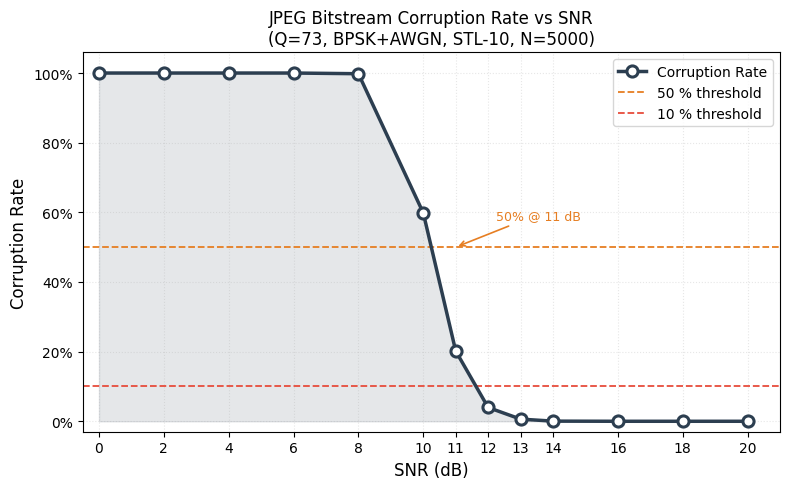

Saved: corruption_vs_snr.png


In [16]:
# ── Plot 1: Corruption Rate vs SNR ────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(SNR_DB, corruption_rates,
        color='#2c3e50', linewidth=2.5, marker='o', markersize=8,
        markerfacecolor='white', markeredgewidth=2.2, zorder=3,
        label='Corruption Rate')
ax.fill_between(SNR_DB, corruption_rates, alpha=0.12, color='#2c3e50')

# Threshold guide lines
ax.axhline(0.5, color='#e67e22', linestyle='--', linewidth=1.3,
           label='50 % threshold', zorder=2)
ax.axhline(0.1, color='#e74c3c', linestyle='--', linewidth=1.3,
           label='10 % threshold', zorder=2)

# Annotate the critical SNR (first point below 50%)
for i, (s, c) in enumerate(zip(SNR_DB, corruption_rates)):
    if c <= 0.5:
        ax.annotate(f'  50% @ {s} dB', xy=(s, 0.5),
                    fontsize=9, color='#e67e22',
                    arrowprops=dict(arrowstyle='->', color='#e67e22', lw=1.2),
                    xytext=(s + 1, 0.58))
        break

ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('Corruption Rate', fontsize=12)
ax.set_title(f'JPEG Bitstream Corruption Rate vs SNR\n'
             f'(Q={JPEG_Q}, BPSK+AWGN, STL-10, N={N_IMAGES})', fontsize=12)
ax.set_xlim(-0.5, 21)
ax.set_ylim(-0.03, 1.06)
ax.set_xticks(SNR_DB)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.grid(True, alpha=0.3, linestyle=':')
ax.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('results/corruption_vs_snr.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: corruption_vs_snr.png")


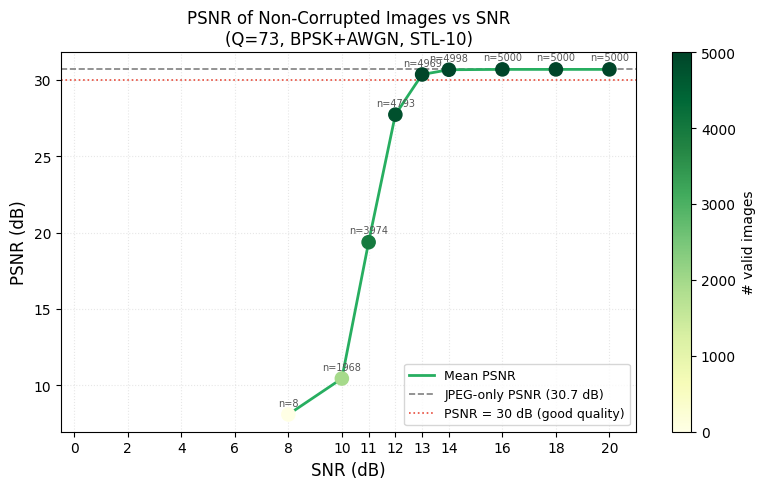

Saved: psnr_noncorrupted_vs_snr.png


In [17]:
# ── Plot 2: PSNR vs SNR (non-corrupted images only) ───────────────────────────

snr_valid  = [s for s, p in zip(SNR_DB, mean_psnrs) if not np.isnan(p)]
psnr_valid = [p for p in mean_psnrs if not np.isnan(p)]
n_valid    = [n for s, n in zip(SNR_DB, n_valid_per_snr)
              if not np.isnan(mean_psnrs[SNR_DB.index(s)])]

fig, ax = plt.subplots(figsize=(8, 5))

sc = ax.scatter(snr_valid, psnr_valid, c=n_valid, cmap='YlGn',
                s=90, zorder=4, vmin=0, vmax=N_IMAGES)
ax.plot(snr_valid, psnr_valid, color='#27ae60', linewidth=2,
        linestyle='-', zorder=3, label='Mean PSNR')
plt.colorbar(sc, ax=ax, label='# valid images')

# JPEG-only reference (noise-free baseline)
jpeg_psnr_ref = np.nanmax(psnr_valid) if psnr_valid else 35.0
ax.axhline(jpeg_psnr_ref, color='gray', linestyle='--', linewidth=1.2,
           label=f'JPEG-only PSNR ({jpeg_psnr_ref:.1f} dB)')
ax.axhline(30, color='#e74c3c', linestyle=':', linewidth=1.2,
           label='PSNR = 30 dB (good quality)')

# Annotate sample counts
for s, p, n in zip(snr_valid, psnr_valid, n_valid):
    ax.annotate(f'n={n}', xy=(s, p), fontsize=7, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points', color='#555')

ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('PSNR (dB)', fontsize=12)
ax.set_title(f'PSNR of Non-Corrupted Images vs SNR\n'
             f'(Q={JPEG_Q}, BPSK+AWGN, STL-10)', fontsize=12)
ax.set_xlim(-0.5, 21)
ax.set_xticks(SNR_DB)
ax.grid(True, alpha=0.3, linestyle=':')
ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('results/psnr_noncorrupted_vs_snr.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: psnr_noncorrupted_vs_snr.png")


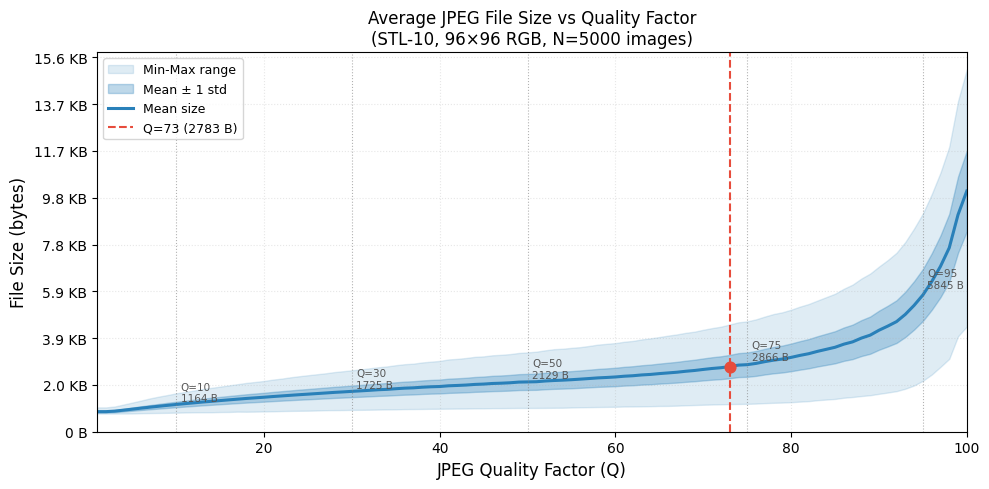

Q=73 mean size: 2783 bytes (2.72 KB, ~22,267 bits)
Saved: filesize_vs_quality.png


In [19]:
# ── Plot: Average JPEG File Size (bytes) vs Quality Factor Q ─────────────────
N_FS = 5000
_fs_imgs = raw_images[:N_FS]

Q_RANGE = list(range(1, 101))   # Q = 1 .. 100

mean_bytes, std_bytes, min_bytes, max_bytes = [], [], [], []

for q in Q_RANGE:
    sizes = [len(jpeg_encode(img, q)) for img in _fs_imgs]
    mean_bytes.append(np.mean(sizes))
    std_bytes.append(np.std(sizes))
    min_bytes.append(np.min(sizes))
    max_bytes.append(np.max(sizes))

mean_bytes = np.array(mean_bytes)
std_bytes  = np.array(std_bytes)
min_bytes  = np.array(min_bytes)
max_bytes  = np.array(max_bytes)

fig, ax = plt.subplots(figsize=(10, 5))

# Min-max band
ax.fill_between(Q_RANGE, min_bytes, max_bytes,
                alpha=0.15, color='#2980b9', label='Min-Max range')
# Std band
ax.fill_between(Q_RANGE, mean_bytes - std_bytes, mean_bytes + std_bytes,
                alpha=0.30, color='#2980b9', label='Mean ± 1 std')
# Mean line
ax.plot(Q_RANGE, mean_bytes, color='#2980b9', linewidth=2.2, label='Mean size')

# Mark Q=73 (experiment quality)
q73_bytes = mean_bytes[72]          # index 72 = Q 73
ax.axvline(73, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Q=73 ({q73_bytes:.0f} B)')
ax.scatter([73], [q73_bytes], color='#e74c3c', s=60, zorder=5)

# Secondary x-axis markers for common qualities
for q_mark in [10, 30, 50, 75, 95]:
    ax.axvline(q_mark, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.text(q_mark + 0.5, mean_bytes[q_mark - 1] * 1.04,
            f'Q={q_mark}\n{mean_bytes[q_mark-1]:.0f} B',
            fontsize=7.5, color='#555', va='bottom')

ax.set_xlabel('JPEG Quality Factor (Q)', fontsize=12)
ax.set_ylabel('File Size (bytes)', fontsize=12)
ax.set_title(f'Average JPEG File Size vs Quality Factor\n'
             f'(STL-10, 96×96 RGB, N={N_FS} images)', fontsize=12)
ax.set_xlim(1, 100)
ax.set_ylim(0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1024:.1f} KB' if v >= 1024 else f'{v:.0f} B'))
ax.grid(True, alpha=0.3, linestyle=':')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('results/filesize_vs_quality.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Q=73 mean size: {q73_bytes:.0f} bytes ({q73_bytes/1024:.2f} KB, ~{int(q73_bytes*8):,} bits)")
print("Saved: filesize_vs_quality.png")
